In [337]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import yfinance as yf
import scipy.stats as stats

In [4]:
df = pd.read_csv("../financial_data/vinfast_stock_data.csv")

In [5]:
df

,Date,Open,High,Low,CloseClosing price adjusted for splits.,Adj CloseAdjusted closing price adjusted for splits and dividend and/or capital gain distributions.,Volume
0,27 Apr 2026,4.24,4.340,4.1566,4.215,4.215,443575
1,24 Apr 2026,4.41,4.450,4.3350,4.360,4.360,457200
2,23 Apr 2026,4.57,4.605,4.1400,4.410,4.410,1333100
3,22 Apr 2026,4.88,5.120,4.5800,4.690,4.690,1409000
4,21 Apr 2026,4.41,5.285,4.3750,4.760,4.760,5725900
...,...,...,...,...,...,...,...
1159,13 Sept 2021,9.71,9.710,9.7100,9.710,9.710,400
1160,10 Sept 2021,9.69,9.690,9.6800,9.680,9.680,700
1161,9 Sept 2021,9.61,9.691,9.6100,9.682,9.682,400
1162,8 Sept 2021,9.71,9.710,9.7100,9.710,9.710,3700


In [6]:
df.columns = ['date', 'open', 'high', 'low', 'adjusted_close_for_splits', 'adjusted_close_for_splits_dividend_capital_gain', 'volume']

In [7]:
df.shape

(1164, 7)

In [8]:
df.isna().sum()

date                                               0
open                                               0
high                                               0
low                                                0
adjusted_close_for_splits                          0
adjusted_close_for_splits_dividend_capital_gain    0
volume                                             0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [20]:
df['date'] = pd.to_datetime(df['date'], format="mixed")


In [26]:
df = df.sort_values(['date'],ascending=True) 
df


,level_0,index,date,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume
0,0,1163,2021-09-07,9.93,9.980,9.7970,9.797,9.797,3700
1,1,1162,2021-09-08,9.71,9.710,9.7100,9.710,9.710,3700
2,2,1161,2021-09-09,9.61,9.691,9.6100,9.682,9.682,400
3,3,1160,2021-09-10,9.69,9.690,9.6800,9.680,9.680,700
4,4,1159,2021-09-13,9.71,9.710,9.7100,9.710,9.710,400
...,...,...,...,...,...,...,...,...,...
1159,1159,4,2026-04-21,4.41,5.285,4.3750,4.760,4.760,5725900
1160,1160,3,2026-04-22,4.88,5.120,4.5800,4.690,4.690,1409000
1161,1161,2,2026-04-23,4.57,4.605,4.1400,4.410,4.410,1333100
1162,1162,1,2026-04-24,4.41,4.450,4.3350,4.360,4.360,457200


In [27]:
df.drop(['level_0', 'index'],axis=1,inplace=True) 
df

,date,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume
0,2021-09-07,9.93,9.980,9.7970,9.797,9.797,3700
1,2021-09-08,9.71,9.710,9.7100,9.710,9.710,3700
2,2021-09-09,9.61,9.691,9.6100,9.682,9.682,400
3,2021-09-10,9.69,9.690,9.6800,9.680,9.680,700
4,2021-09-13,9.71,9.710,9.7100,9.710,9.710,400
...,...,...,...,...,...,...,...
1159,2026-04-21,4.41,5.285,4.3750,4.760,4.760,5725900
1160,2026-04-22,4.88,5.120,4.5800,4.690,4.690,1409000
1161,2026-04-23,4.57,4.605,4.1400,4.410,4.410,1333100
1162,2026-04-24,4.41,4.450,4.3350,4.360,4.360,457200


In [28]:
df.corr(numeric_only=True)

,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain
open,1.000000,0.977752,0.981942,0.966705,0.966705
high,0.977752,1.000000,0.964275,0.985585,0.985585
low,0.981942,0.964275,1.000000,0.982136,0.982136
adjusted_close_for_splits,0.966705,0.985585,0.982136,1.000000,1.000000
adjusted_close_for_splits_dividend_capital_gain,0.966705,0.985585,0.982136,1.000000,1.000000


In [31]:
plt.style.use("bmh")

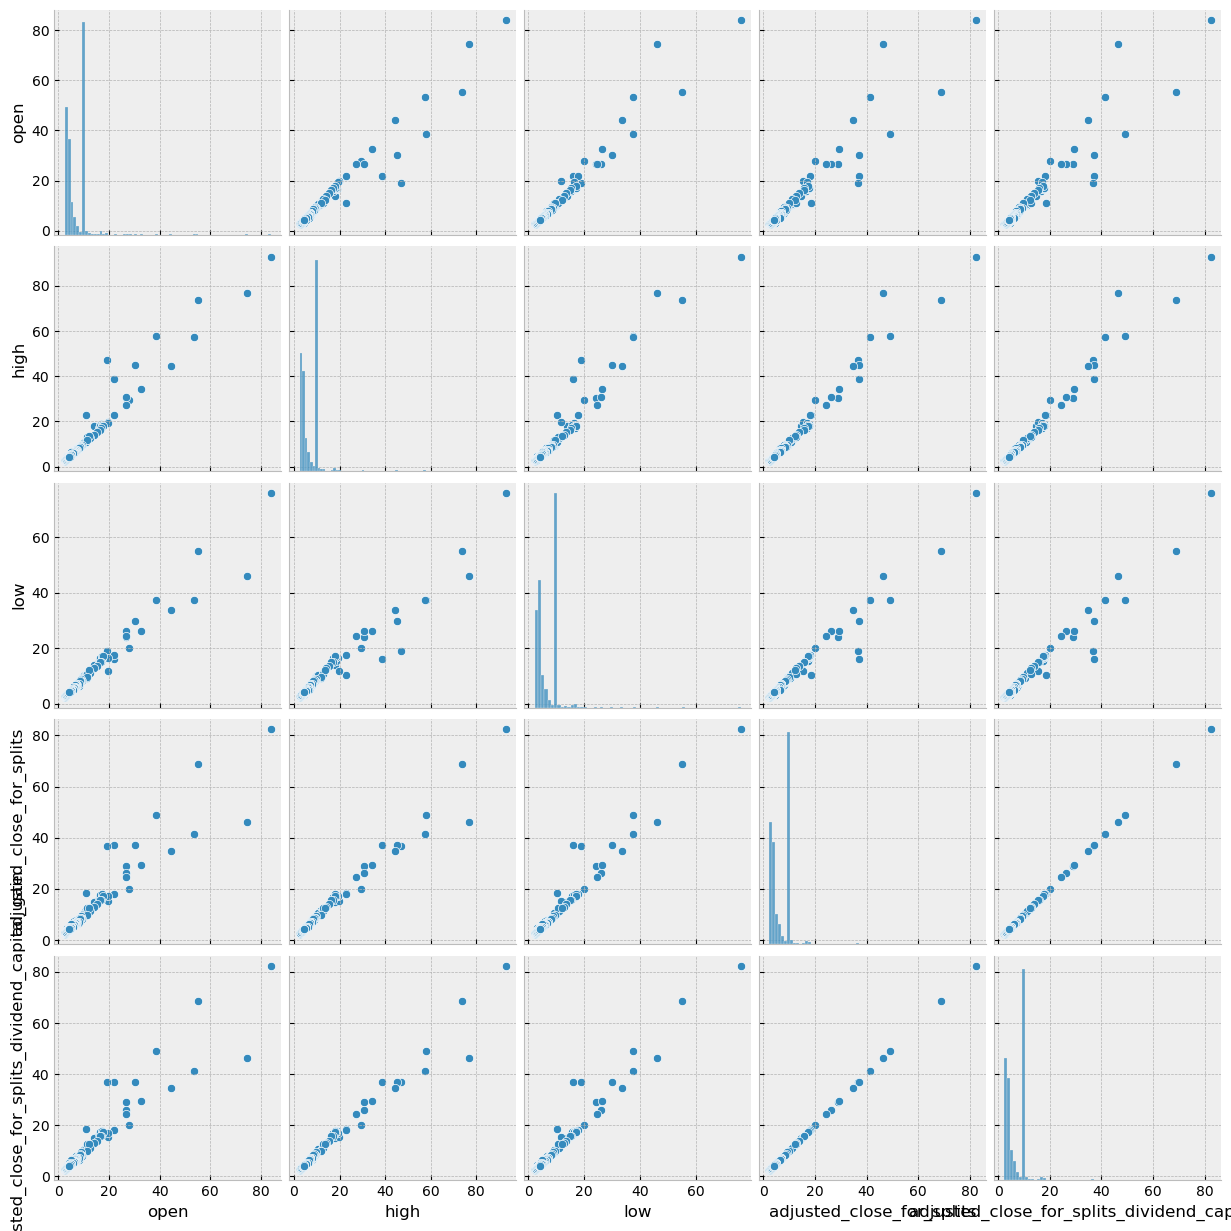

In [32]:
sns.pairplot(df)

In [33]:
df.index = df.date 
df.drop(['date'],axis=1,inplace=True) 


In [35]:
df

,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume
date,,,,,,
2021-09-07,9.93,9.980,9.7970,9.797,9.797,3700
2021-09-08,9.71,9.710,9.7100,9.710,9.710,3700
2021-09-09,9.61,9.691,9.6100,9.682,9.682,400
2021-09-10,9.69,9.690,9.6800,9.680,9.680,700
2021-09-13,9.71,9.710,9.7100,9.710,9.710,400
...,...,...,...,...,...,...
2026-04-21,4.41,5.285,4.3750,4.760,4.760,5725900
2026-04-22,4.88,5.120,4.5800,4.690,4.690,1409000
2026-04-23,4.57,4.605,4.1400,4.410,4.410,1333100


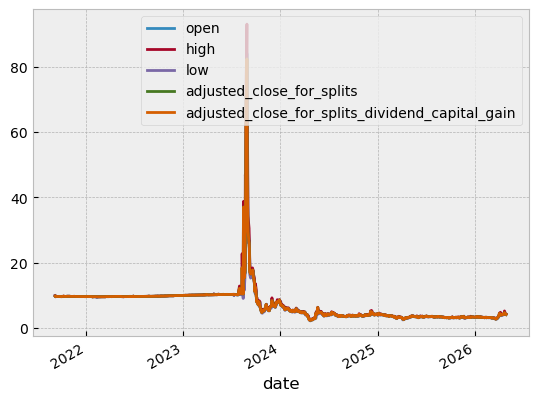

In [42]:
plt.Figure(figsize=(10,10))
df.plot(kind='line')

plt.show()

In [576]:
df = df.sort_values(['date'],ascending=True)

df = df[df.date > '2024-01-01']

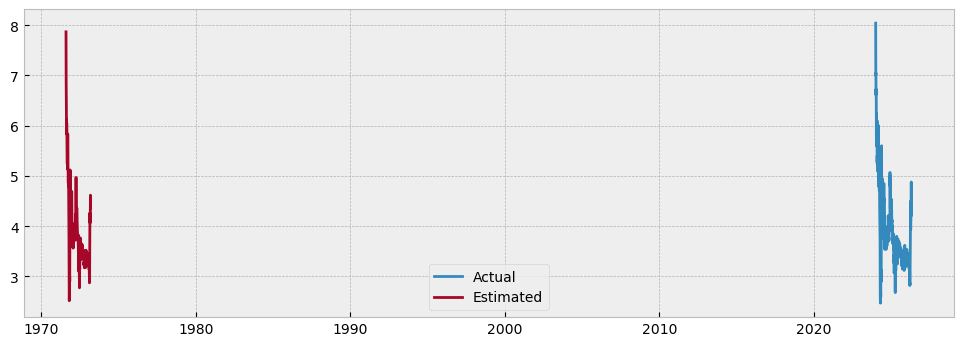

In [581]:
from statsmodels.tsa.seasonal import STL
open_price = pd.DataFrame(df[['open', 'date']])


stl = STL(open_price['open'], period=3) 
result = stl.fit()
seasonal, trend, resid = result.seasonal, result.trend, result.resid 


estimated = trend + seasonal 
plt.figure(figsize=(12,4)) 
plt.plot(open_price.date, open_price.open) 
plt.plot(estimated) 
plt.legend(['Actual', 'Estimated'])
plt.show()

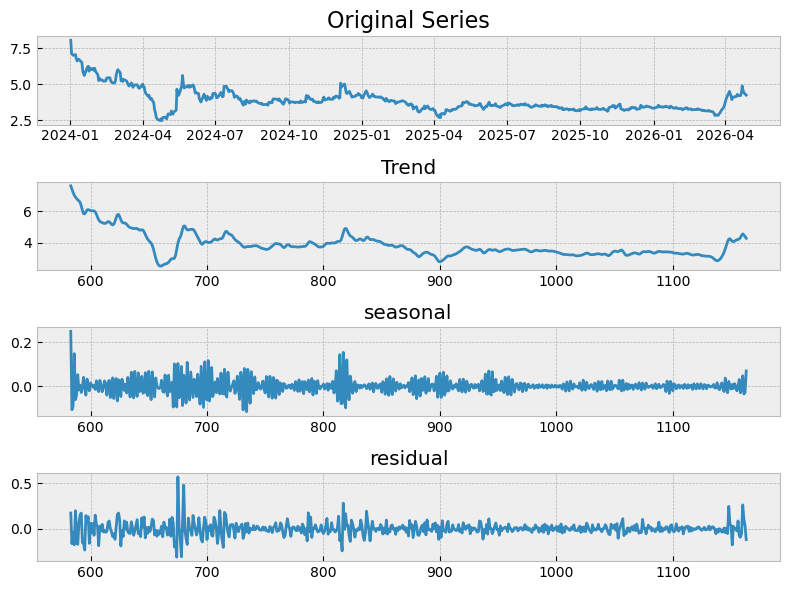

In [582]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid 

plt.figure(figsize=(8,6)) 
plt.subplot(4,1,1) 
plt.plot(df.date, df['open']) 
plt.title("Original Series", fontsize=16) 

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend") 

plt.subplot(4,1,3) 
plt.plot(seasonal) 
plt.title("seasonal") 

plt.subplot(4,1,4) 
plt.plot(resid) 
plt.title("residual")
plt.tight_layout()

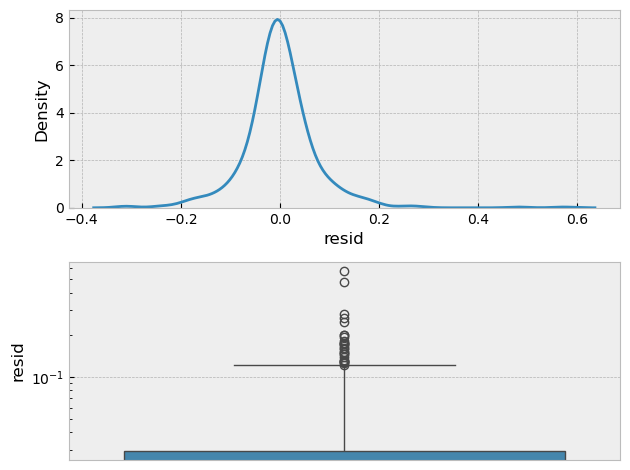

Shapiro -> ShapiroResult(statistic=0.8905725441187925, pvalue=6.902005422612242e-20)


In [583]:
fig, axes=plt.subplots(2) 

sns.kdeplot(resid, ax=axes[0])
sns.boxplot(resid, ax=axes[1])
axes[1].set_yscale("log") 
plt.tight_layout()
plt.show()

import scipy.stats as stats 


print (f"Shapiro -> {stats.shapiro(resid)}")

In [584]:
df

,date,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume,open_imputed,high_imputed,low_imputed,...,adjusted_close_for_splits_dividend_capital_gain_imputed,volume_imputed,lagged_volume,lagged_adjusted_close_for_splits,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low,day,month,year
583,2024-01-02,8.040,8.050,7.0000,7.050,8.37,6666200,8.040,8.050,7.0000,...,8.37,359650.0,2816600.0,8.37,8.64,8.560,8.080,2,1,2024
584,2024-01-03,7.135,7.210,6.8350,7.080,7.05,4709600,7.135,7.210,6.8350,...,7.05,359650.0,359650.0,7.05,8.37,8.050,7.000,3,1,2024
585,2024-01-04,7.070,7.130,6.9000,7.070,7.08,3466600,7.070,7.130,6.9000,...,7.08,3466600.0,359650.0,7.08,7.05,7.210,6.835,4,1,2024
586,2024-01-05,7.000,7.060,6.9000,7.020,7.07,1939900,7.000,7.060,6.9000,...,7.07,1939900.0,3466600.0,7.07,7.08,7.130,6.900,5,1,2024
587,2024-01-08,7.050,7.190,6.7500,6.790,7.02,3767900,7.050,7.190,6.7500,...,7.02,3767900.0,1939900.0,7.02,7.07,7.060,6.900,8,1,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159,2026-04-21,4.410,5.285,4.3750,4.760,4.35,5725900,4.410,5.285,4.3750,...,4.35,359650.0,801300.0,4.35,4.21,4.400,4.190,21,4,2026
1160,2026-04-22,4.880,5.120,4.5800,4.690,4.76,1409000,4.880,5.120,4.5800,...,4.76,1409000.0,359650.0,4.76,4.35,5.285,4.375,22,4,2026
1161,2026-04-23,4.570,4.605,4.1400,4.410,4.69,1333100,4.570,4.605,4.1400,...,4.69,1333100.0,1409000.0,4.69,4.76,5.120,4.580,23,4,2026
1162,2026-04-24,4.410,4.450,4.3350,4.360,4.41,457200,4.410,4.450,4.3350,...,4.41,457200.0,1333100.0,4.41,4.69,4.605,4.140,24,4,2026


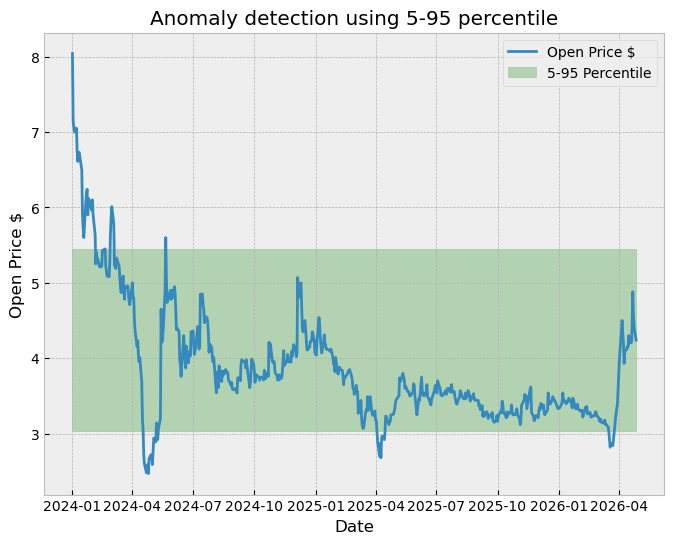

In [585]:
plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = np.percentile(df.open, 95) 
lower = np.percentile(df.open, 5) 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 5-95 percentile") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '5-95 Percentile'])
plt.show()

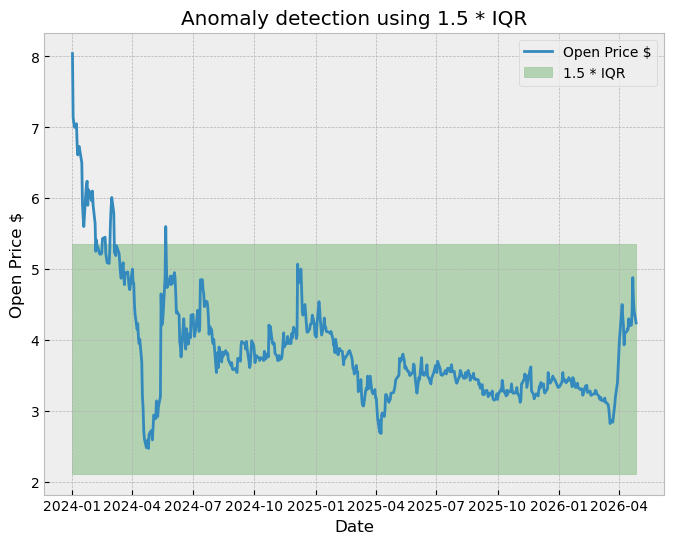

In [586]:
# using IQR

iqr = stats.iqr(df['open']) 




plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = (1.5 * iqr) + np.percentile(df.open, 75)
lower = np.percentile(df.open, 25) - (1.5 * iqr)

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 1.5 * IQR") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '1.5 * IQR'])
plt.show()

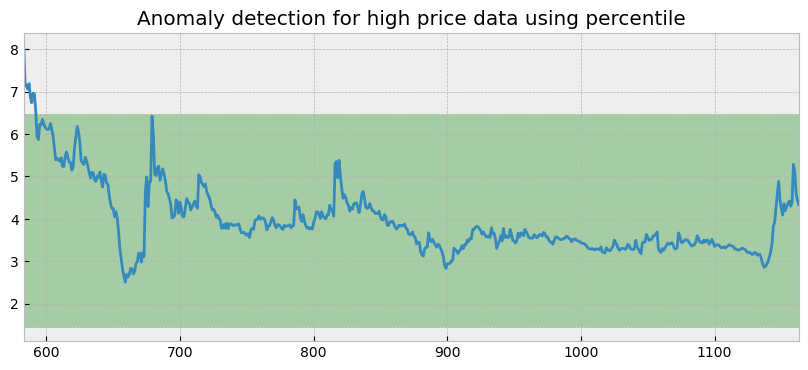

In [587]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['high'].mean() 
open_dev = df['high'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using percentile")
plt.show()

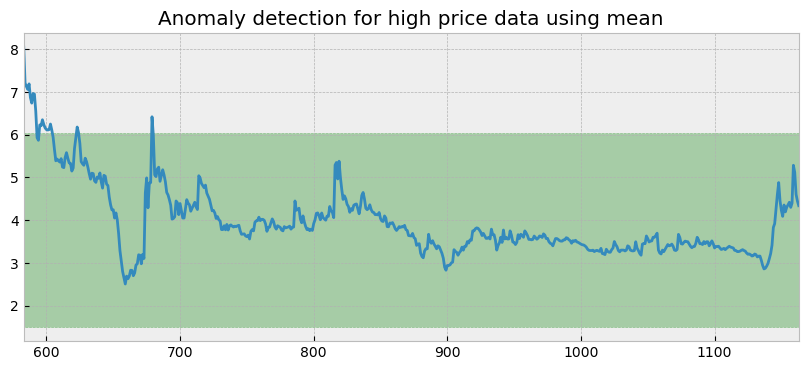

In [588]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['low'].mean() 
open_dev = df['low'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using mean")
plt.show()

In [589]:
df.volume = df.volume.str.replace("-", "0")
df.volume = pd.to_numeric(df.volume)

AttributeError: Can only use .str accessor with string values!

In [590]:
df.iloc[5]

date                                                       2024-01-09 00:00:00
open                                                                      6.75
high                                                                      6.87
low                                                                       6.41
adjusted_close_for_splits                                                 6.65
adjusted_close_for_splits_dividend_capital_gain                           6.79
volume                                                                 3327700
open_imputed                                                              6.75
high_imputed                                                              6.87
low_imputed                                                               6.41
adjusted_close_for_splits_imputed                                         6.65
adjusted_close_for_splits_dividend_capital_gain_imputed                   6.79
volume_imputed                                      

In [591]:
df.index = pd.to_datetime(df.date)
df.drop(['date'],axis=1,inplace=True)

In [593]:
df.reset_index(inplace=True)

In [651]:
df.columns

df.drop(['open_imputed'],axis=1,inplace=True)

In [652]:

print ("Creating day, month, year...")
df['date'] = pd.to_datetime(df['date'])


df['day'] = df['date'].dt.day 
df['month'] = df['date'].dt.month 
df['year'] = df['date'].dt.year

df = df.sort_values(['date'],ascending=True) 
print ("Splitting into X_train, X_test, Y_train, Y_test...")
X = df[['high','low', 'adjusted_close_for_splits_dividend_capital_gain', 'volume', 'day', 'month', 'year']]
train_size=round(df.shape[0]*0.8)
test_size=round(df.shape[0]*0.2)
# replacing the anomalies
X_train = X.head(train_size) 
X_test = X.tail(test_size)




def impute_median(column): 
    print (f"Computing for column: {column}")
    median = X_train[column].median() 
    print (f"median: {median}")
    std = X_train[column].std() 
    print (f"std: {std}")
    mean = X_train[column].mean() 
    print (f"mean: {mean}")
    # calculating the upper limit

    iqr = stats.iqr(df[column])


    upper = (1.5 * iqr) + np.percentile(X_train[column], 75)
    lower=np.percentile(X_train[column], 25) - (1.5 * iqr)
    print (f"upper: {upper}")
    print (f"lower: {lower}")
    # checking if the value is above or below 
    print ("Imputing...")

    values = [median if value > upper or value < lower else value for value in X_train[column]]
    print ("Done") 
    print ("----------------------")
    return values, median, upper, lower

print ("Imputing...")

# imputing mean for df['open']
iqr = stats.iqr(df['open']) 
upper = (1.5 * iqr) + np.percentile(df['open'], 75)
lower=np.percentile(df['open'], 25) - (1.5 * iqr)
median = df['open'].median()
df['open_imputed'] = [median if value > upper or value < lower else value for value in df['open']]




for column in X_train: 
    # this will impute X_train and X_test simultaneously
    print (f"column: {column}")

    X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)
    
    X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]
    print ("Done...")
    print ("------------------")




# -------------------------- CREATING THE LAGGING
y = df.open_imputed.values.reshape(-1,1)



Y_train = y[0:train_size]
Y_test = y[train_size:df.shape[0]]


Creating day, month, year...
Splitting into X_train, X_test, Y_train, Y_test...
Imputing...
column: high
Computing for column: high
median: 3.83
std: 0.8781841086416592
mean: 4.068238709677419
upper: 5.665
lower: 2.1850000000000005
Imputing...
Done
----------------------
Done...
------------------
column: low
Computing for column: low
median: 3.69
std: 0.7996907875262981
mean: 3.8597591397849462
upper: 5.205000000000001
lower: 2.244999999999999
Imputing...
Done
----------------------
Done...
------------------
column: adjusted_close_for_splits_dividend_capital_gain
Computing for column: adjusted_close_for_splits_dividend_capital_gain
median: 3.75
std: 0.8579145832193796
mean: 3.9712150537634407
upper: 5.4399999999999995
lower: 2.2300000000000004
Imputing...
Done
----------------------
Done...
------------------
column: volume
Computing for column: volume
median: 736800.0
std: 1372478.8442926763
mean: 1188062.7956989247
upper: 2611500.0
lower: -724300.0
Imputing...
Done
----------------

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/4203199214.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/4203199214.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/42

In [653]:
print (np.shape(Y_train)) 
print (np.shape(Y_test))

(465, 1)
(116, 1)


In [654]:
print (np.shape(X_train)) 
print (np.shape(X_test))

(465, 14)
(116, 14)


In [655]:
X_test

,high,low,adjusted_close_for_splits_dividend_capital_gain,volume,day,month,year,high_imputed,low_imputed,adjusted_close_for_splits_dividend_capital_gain_imputed,volume_imputed,day_imputed,month_imputed,year_imputed
465,3.450,3.3210,3.400,417500,7,11,2025,3.450,3.3210,3.400,417500.0,7,11,2025
466,3.630,3.4200,3.430,780000,10,11,2025,3.630,3.4200,3.430,780000.0,10,11,2025
467,3.570,3.4600,3.530,277200,11,11,2025,3.570,3.4600,3.530,277200.0,11,11,2025
468,3.490,3.4000,3.485,474600,12,11,2025,3.490,3.4000,3.485,474600.0,12,11,2025
469,3.510,3.3300,3.470,338500,13,11,2025,3.510,3.3300,3.470,338500.0,13,11,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,5.285,4.3750,4.350,5725900,21,4,2026,5.285,4.3750,4.350,736800.0,21,4,2026
577,5.120,4.5800,4.760,1409000,22,4,2026,5.120,4.5800,4.760,1409000.0,22,4,2026
578,4.605,4.1400,4.690,1333100,23,4,2026,4.605,4.1400,4.690,1333100.0,23,4,2026
579,4.450,4.3350,4.410,457200,24,4,2026,4.450,4.3350,4.410,457200.0,24,4,2026


In [656]:
df.shape

(581, 11)

In [657]:
lagged_volume = X_train['volume_imputed'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

X_train['lagged_volume'] = lagged_volume 

# lagged adjusted close



lagged_adjusted_close = X_train['adjusted_close_for_splits_dividend_capital_gain_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_train['lagged_adjusted_close_for_splits_dividend_capital_gain'] = lagged_adjusted_close



# lagged adjusted high
lagged_high = X_train['high_imputed'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
X_train['lagged_high'] = lagged_high 

# lagged low 
lagged_low = X_train['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_train['lagged_low'] = lagged_low 

X_train.head()
# ----------------------------

lagged_volume = X_test['volume_imputed'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

X_test['lagged_volume'] = lagged_volume 

# lagged adjusted close
lagged_adjusted_close = X_test['adjusted_close_for_splits_dividend_capital_gain_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_test['lagged_adjusted_close_for_splits_dividend_capital_gain'] = lagged_adjusted_close




# lagged adjusted high
lagged_high = X_test['high_imputed'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
X_test['lagged_high'] = lagged_high 

# lagged low 
lagged_low = X_test['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_test['lagged_low'] = lagged_low 







/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/2341579483.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['lagged_volume'] = lagged_volume
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/2341579483.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['lagged_adjusted_close_for_splits_dividend_capital_gain'] = lagged_adjusted_close
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/2341579483.py:22: SettingWithCopyWarning: 
A value is tryin

In [658]:
X_train.head()

,high,low,adjusted_close_for_splits_dividend_capital_gain,volume,day,month,year,high_imputed,low_imputed,adjusted_close_for_splits_dividend_capital_gain_imputed,volume_imputed,day_imputed,month_imputed,year_imputed,lagged_volume,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low
0,8.05,7.000,8.37,6666200,2,1,2024,3.83,3.69,3.75,736800.0,2,1,2024,0.0,0.00,0.00,0.00
1,7.21,6.835,7.05,4709600,3,1,2024,3.83,3.69,3.75,736800.0,3,1,2024,736800.0,3.75,3.83,3.69
2,7.13,6.900,7.08,3466600,4,1,2024,3.83,3.69,3.75,736800.0,4,1,2024,736800.0,3.75,3.83,3.69
3,7.06,6.900,7.07,1939900,5,1,2024,3.83,3.69,3.75,1939900.0,5,1,2024,736800.0,3.75,3.83,3.69
4,7.19,6.750,7.02,3767900,8,1,2024,3.83,3.69,3.75,736800.0,8,1,2024,1939900.0,3.75,3.83,3.69


In [659]:
X_test

,high,low,adjusted_close_for_splits_dividend_capital_gain,volume,day,month,year,high_imputed,low_imputed,adjusted_close_for_splits_dividend_capital_gain_imputed,volume_imputed,day_imputed,month_imputed,year_imputed,lagged_volume,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low
465,3.450,3.3210,3.400,417500,7,11,2025,3.450,3.3210,3.400,417500.0,7,11,2025,0.0,0.000,0.000,0.000
466,3.630,3.4200,3.430,780000,10,11,2025,3.630,3.4200,3.430,780000.0,10,11,2025,417500.0,3.400,3.450,3.321
467,3.570,3.4600,3.530,277200,11,11,2025,3.570,3.4600,3.530,277200.0,11,11,2025,780000.0,3.430,3.630,3.420
468,3.490,3.4000,3.485,474600,12,11,2025,3.490,3.4000,3.485,474600.0,12,11,2025,277200.0,3.530,3.570,3.460
469,3.510,3.3300,3.470,338500,13,11,2025,3.510,3.3300,3.470,338500.0,13,11,2025,474600.0,3.485,3.490,3.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,5.285,4.3750,4.350,5725900,21,4,2026,5.285,4.3750,4.350,736800.0,21,4,2026,801300.0,4.210,4.400,4.190
577,5.120,4.5800,4.760,1409000,22,4,2026,5.120,4.5800,4.760,1409000.0,22,4,2026,736800.0,4.350,5.285,4.375
578,4.605,4.1400,4.690,1333100,23,4,2026,4.605,4.1400,4.690,1333100.0,23,4,2026,1409000.0,4.760,5.120,4.580
579,4.450,4.3350,4.410,457200,24,4,2026,4.450,4.3350,4.410,457200.0,24,4,2026,1333100.0,4.690,4.605,4.140


In [660]:
X_train = X_train[['day', 'month', 'year', 'lagged_volume', 'lagged_adjusted_close_for_splits_dividend_capital_gain', 'lagged_high', 'lagged_low']].iloc[1:]
X_test = X_test[['day', 'month', 'year', 'lagged_volume', 'lagged_adjusted_close_for_splits_dividend_capital_gain', 'lagged_high', 'lagged_low']].iloc[1:]

Y_train = Y_train[1:]
Y_test = Y_test[1:]


X_train.head()

,day,month,year,lagged_volume,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low
1,3,1,2024,736800.0,3.75,3.83,3.69
2,4,1,2024,736800.0,3.75,3.83,3.69
3,5,1,2024,736800.0,3.75,3.83,3.69
4,8,1,2024,1939900.0,3.75,3.83,3.69
5,9,1,2024,736800.0,3.75,3.83,3.69


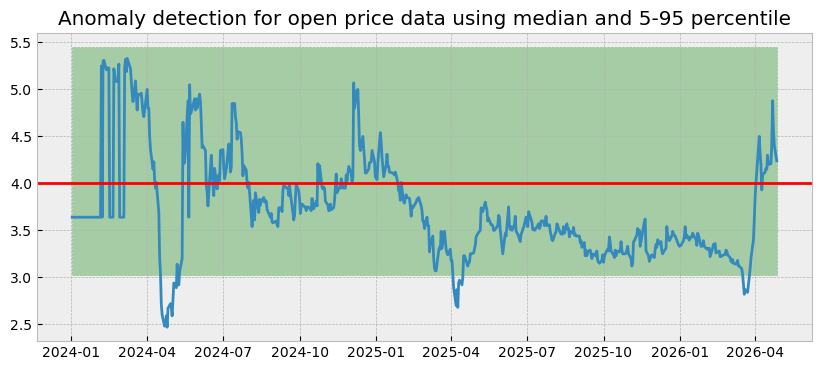

In [661]:


lower=np.percentile(df.open, 5)
upper = np.percentile(df.open, 95) 
plt.figure(figsize=(10,4)) 
plt.plot(df.date, df.open_imputed) 
plt.fill_between([min(df.date), max(df.date)], lower, upper, color='g', alpha=0.3, linestyle='--')


plt.axhline(y=4, color='r')
plt.title("Anomaly detection for open price data using median and 5-95 percentile")
plt.show()

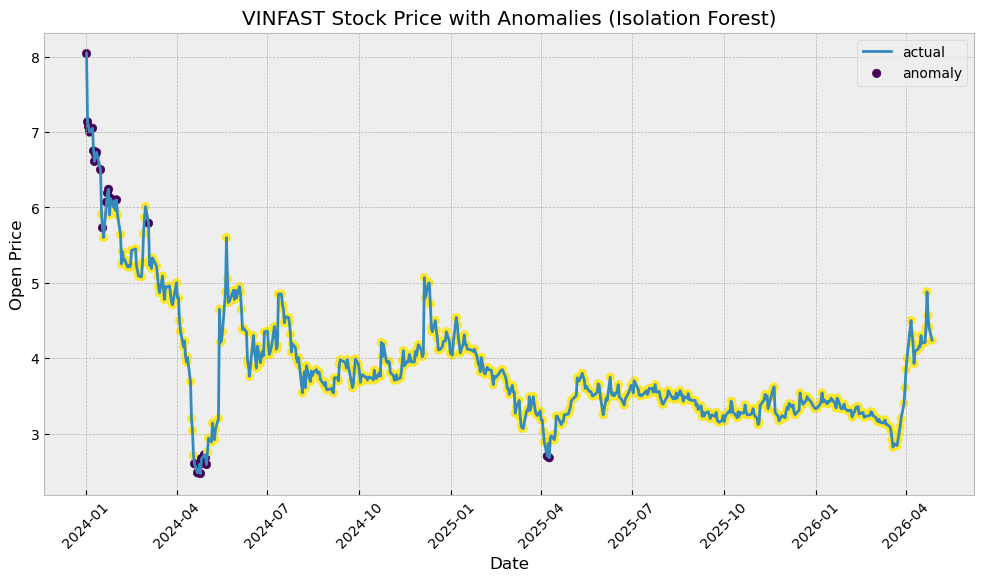

In [662]:
from sklearn.ensemble import IsolationForest

# Prepare the data for Isolation Forest
X = df['open'].values.reshape(-1, 1)

# Train the Isolation Forest model
model = IsolationForest(contamination=0.05)
model.fit(X)

# Predict the anomalies
anomalies = model.predict(X)

# Plot the anomalies
plt.figure(figsize=(12, 6))
plt.plot(df.date, df['open'])
plt.scatter(df.date, df['open'], c=anomalies, label='Anomaly')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('VINFAST Stock Price with Anomalies (Isolation Forest)')
plt.xticks(rotation=45)
plt.legend(['actual', 'anomaly'])
plt.grid(True)

plt.show()

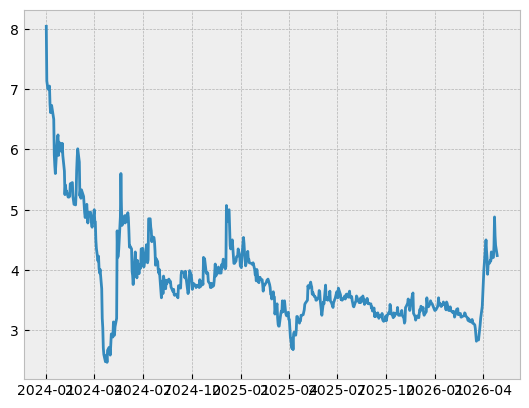

In [663]:
plt.plot(df.date, df.open)

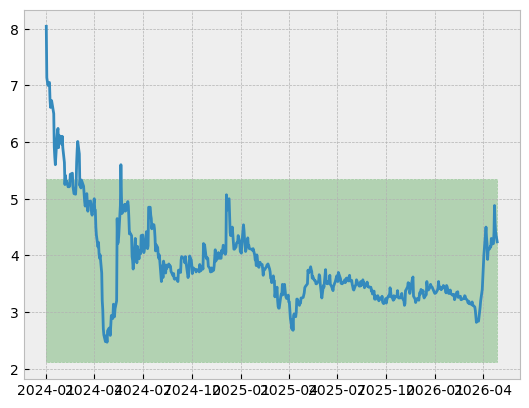

In [664]:
iqr = stats.iqr(df['open']) 

upper = (1.5*iqr) + np.percentile(df['open'], 75)
lower = np.percentile(df['open'], 25) - (1.5*iqr) 

plt.plot(df.date, df.open) 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', linestyle='--', alpha=0.25)

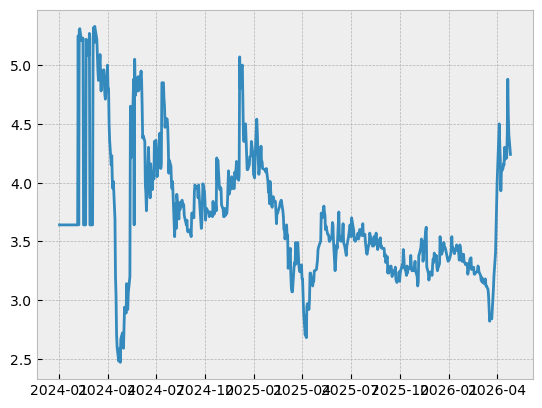

In [665]:
iqr = stats.iqr(df['open']) 

upper = (1.5*iqr) + np.percentile(df['open'], 75)
lower = np.percentile(df['open'], 25) - (1.5*iqr) 

plt.plot(df.date, df.open_imputed) 



In [666]:
df.open_imputed

0      3.64
1      3.64
2      3.64
3      3.64
4      3.64
       ... 
576    4.41
577    4.88
578    4.57
579    4.41
580    4.24
Name: open_imputed, Length: 581, dtype: float64

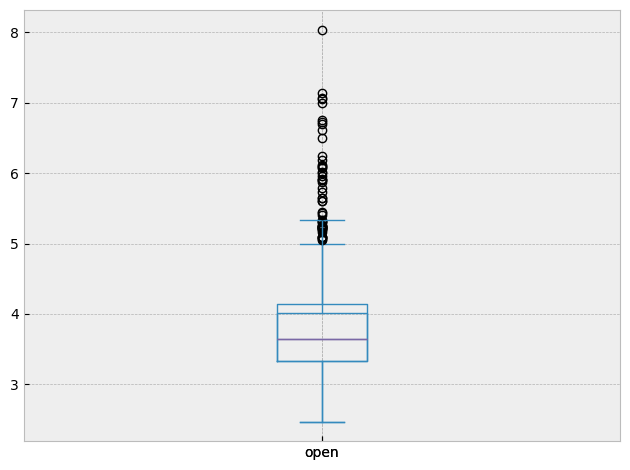

In [667]:
df['open_imputed'].plot(kind='box')
df['open'].plot(kind='box')
plt.tight_layout()

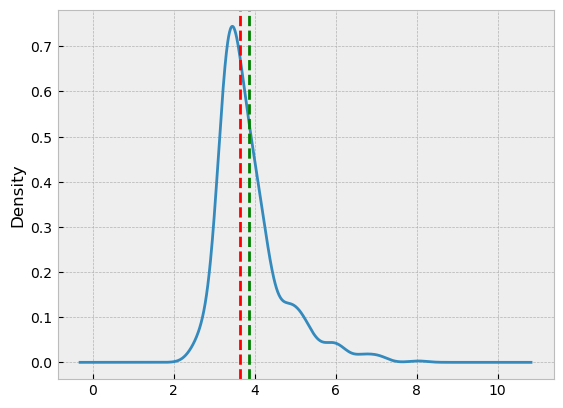

In [668]:

plt.ylabel("Open Price $")

df['open'].plot(kind='kde')
plt.axvline(x=df['open'].median(), color='r', linestyle='--')
plt.axvline(x=df['open'].mean(), color='g', linestyle='--')
plt.show()

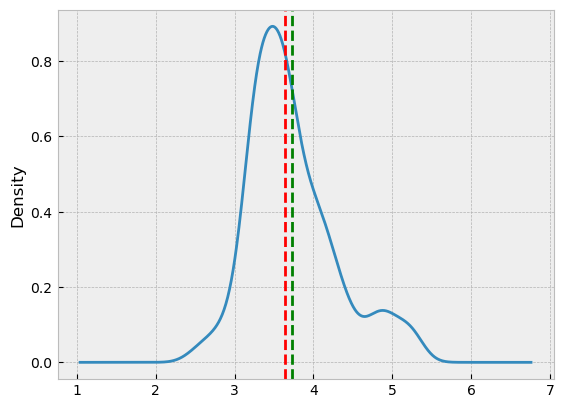

In [670]:

plt.ylabel("Open Price $ imputed")

df['open_imputed'].plot(kind='kde')
plt.axvline(x=df['open_imputed'].median(), color='r', linestyle='--')
plt.axvline(x=df['open_imputed'].mean(), color='g', linestyle='--')
plt.show()

# Building the model

In [671]:
from sklearn.model_selection import train_test_split, GridSearchCV 
from xgboost import XGBRegressor


In [672]:
print (np.shape(X_train)) 
print (np.shape(Y_train)) 
print ("---")
print (np.shape(X_test)) 
print (np.shape(Y_test))

(464, 7)
(464, 1)
---
(115, 7)
(115, 1)


In [673]:
X_train.head()

,day,month,year,lagged_volume,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low
1,3,1,2024,736800.0,3.75,3.83,3.69
2,4,1,2024,736800.0,3.75,3.83,3.69
3,5,1,2024,736800.0,3.75,3.83,3.69
4,8,1,2024,1939900.0,3.75,3.83,3.69
5,9,1,2024,736800.0,3.75,3.83,3.69


In [674]:
model = XGBRegressor() 

model.fit(X_train, Y_train)
pred = model.predict(X_test)

In [675]:
# metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [676]:
np.shape(Y_test)

(115, 1)

In [677]:
np.shape(X_test)

(115, 7)

In [678]:
print (root_mean_squared_error(y_pred=pred, y_true=Y_test))
print (mean_absolute_error(y_pred=pred, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=pred))

0.08326089209848131
0.0555836671580439
0.9535767464588414


In [682]:
Y_test

array([[3.45 ],
       [3.52 ],
       [3.46 ],
       [3.5  ],
       [3.33 ],
       [3.49 ],
       [3.54 ],
       [3.59 ],
       [3.62 ],
       [3.282],
       [3.23 ],
       [3.17 ],
       [3.2  ],
       [3.24 ],
       [3.21 ],
       [3.3  ],
       [3.35 ],
       [3.32 ],
       [3.4  ],
       [3.35 ],
       [3.38 ],
       [3.28 ],
       [3.25 ],
       [3.27 ],
       [3.31 ],
       [3.54 ],
       [3.45 ],
       [3.43 ],
       [3.39 ],
       [3.44 ],
       [3.49 ],
       [3.46 ],
       [3.44 ],
       [3.37 ],
       [3.35 ],
       [3.33 ],
       [3.34 ],
       [3.39 ],
       [3.43 ],
       [3.54 ],
       [3.42 ],
       [3.45 ],
       [3.395],
       [3.43 ],
       [3.42 ],
       [3.43 ],
       [3.47 ],
       [3.4  ],
       [3.34 ],
       [3.47 ],
       [3.45 ],
       [3.33 ],
       [3.33 ],
       [3.34 ],
       [3.39 ],
       [3.33 ],
       [3.3  ],
       [3.31 ],
       [3.3  ],
       [3.31 ],
       [3.22 ],
       [3.31 ],
       [

In [684]:
df.tail(test_size).date

465   2025-11-07
466   2025-11-10
467   2025-11-11
468   2025-11-12
469   2025-11-13
         ...    
576   2026-04-21
577   2026-04-22
578   2026-04-23
579   2026-04-24
580   2026-04-27
Name: date, Length: 116, dtype: datetime64[ns]

In [686]:
np.shape(pred)

(115,)

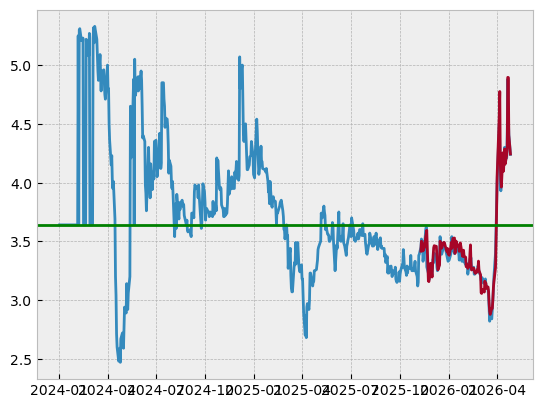

In [687]:
# plotting


plt.plot(df.date, df.open_imputed)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.axhline(y=df['open'].median(), color='g')

Text(0.5, 1.0, 'Zoomed in VINFAST opening prices prediction. R2 = 0.954')

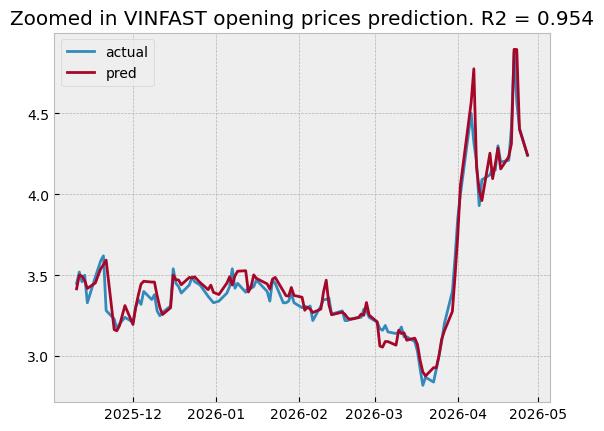

In [716]:
plt.plot(df.tail(test_size).date.iloc[1:], Y_test)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.legend(['actual', 'pred'])

plt.title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")

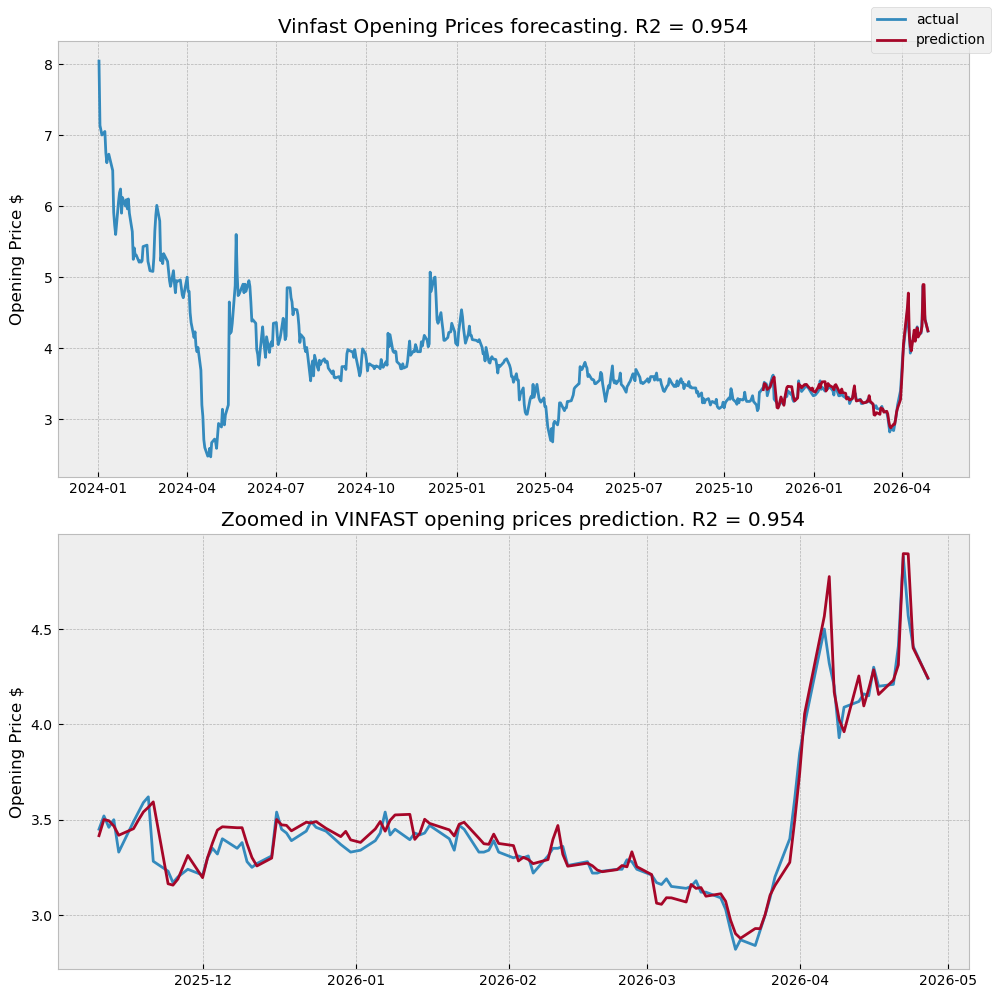

In [727]:
# plotting

fig, axes=plt.subplots(2, figsize=(10,10))




axes[0].plot(df.date, df.open)
axes[0].plot(df.tail(test_size).date.iloc[1:], pred)



axes[0].set_title(f"Vinfast Opening Prices forecasting. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[0].set_ylabel("Opening Price $")

# ---------

axes[1].plot(df.tail(test_size).date.iloc[1:], Y_test)
axes[1].plot(df.tail(test_size).date.iloc[1:], pred)



axes[1].set_title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[1].set_ylabel("Opening Price $")
fig.legend(['actual', 'prediction'])

fig.align_ylabels()

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Y test')

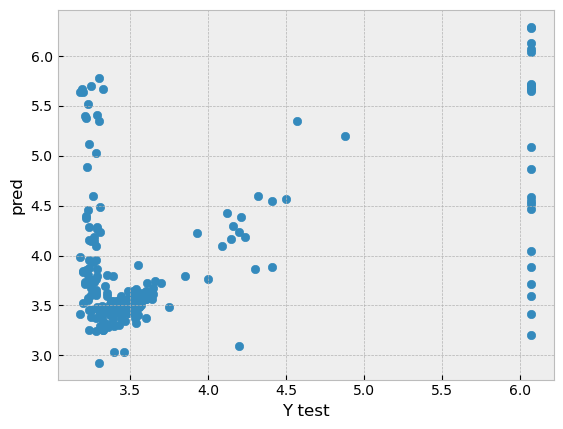

In [552]:
plt.scatter(Y_test, pred) 
plt.ylabel("pred") 
plt.xlabel("Y test")

In [498]:
X_train.shape

(930, 7)

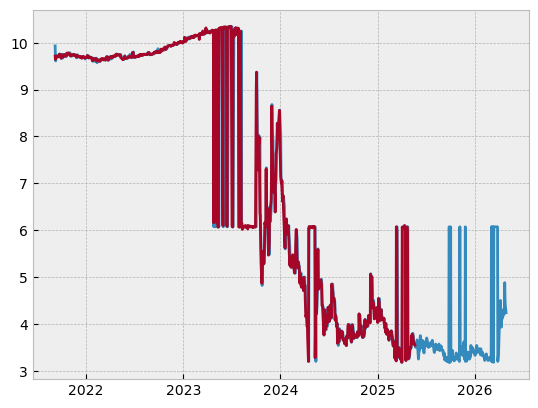

In [553]:
# plotting
train_pred = model.predict(X_train)

plt.plot(df.date, df.open_imputed)
plt.plot(df.date.iloc[0:930], train_pred)

In [701]:
# calculating the residuals 

residuals = np.reshape(np.subtract(Y_test, pred), (-1,1))

In [702]:
print (f"Median residuals: {np.median(residuals)}")
print (f"Mean Residuals: {np.mean(residuals)}")

Median residuals: -0.025882081985473704
Mean Residuals: -0.020549464582360295


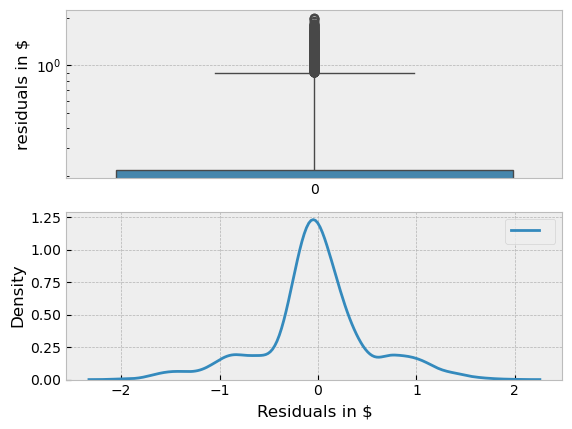

In [703]:
fig, axes = plt.subplots(2)

sns.boxplot(residuals, ax=axes[0])

axes[0].set_yscale("log") 
axes[0].set_ylabel("residuals in $")

sns.kdeplot(residuals, ax=axes[1]) 
axes[1].set_xlabel("Residuals in $") 
axes[1].legend([''])


plt.show()

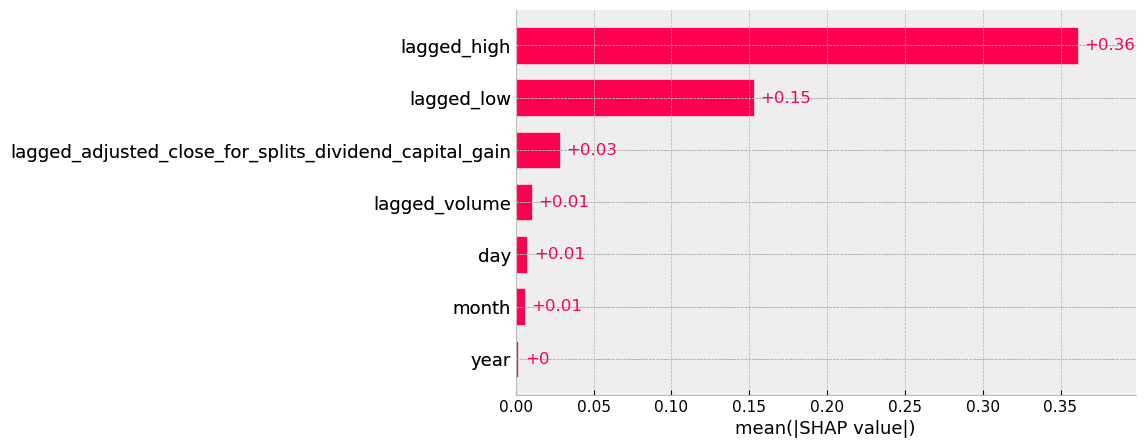

In [704]:
import shap 


explainer = shap.TreeExplainer(model) 
shap_values = explainer(X_test) 


shap.plots.bar(shap_values)

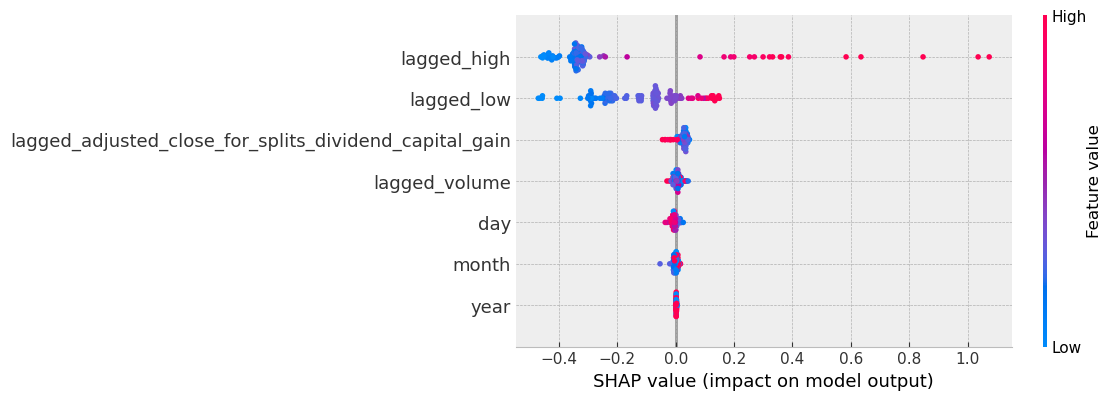

In [705]:
shap.plots.beeswarm(shap_values)

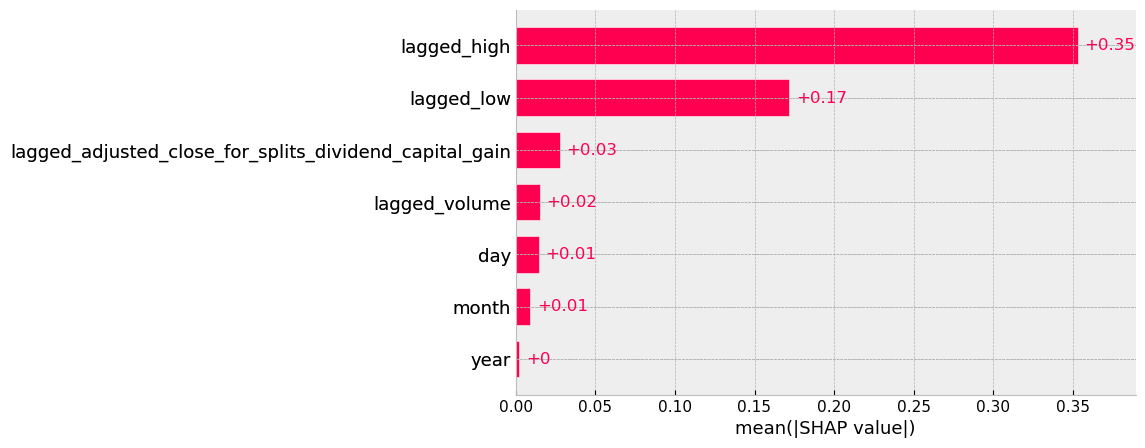

In [728]:



train_shap_values = explainer(X_train) 


shap.plots.bar(train_shap_values)

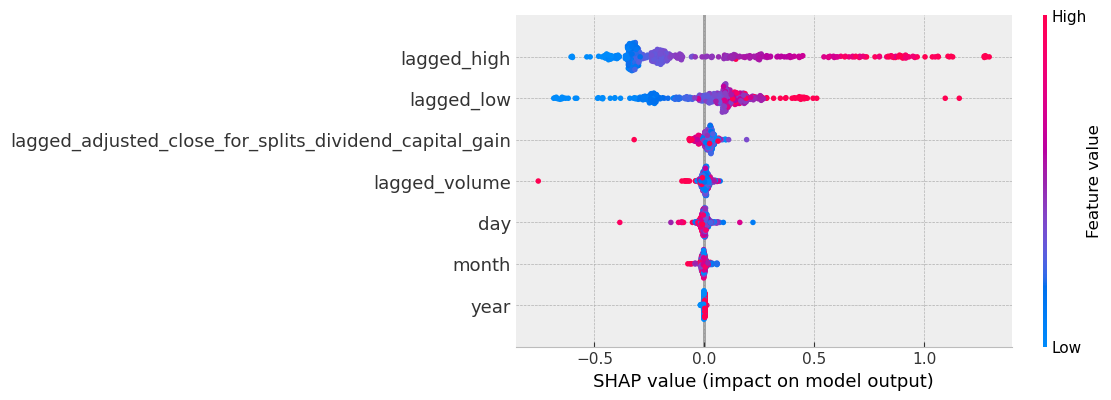

In [729]:



train_shap_values = explainer(X_train) 


shap.plots.beeswarm(train_shap_values)

In [732]:
# test prediction 

test_data = pd.DataFrame({

    'day': [29],
    'month': [4],
    'year': [2026],
    'lagged_volume': [728407],
    'lagged_adjusted_close_for_splits_dividend_capital_gain': [4.0346],
    'lagged_high': [4.1950],
    'lagged_low': [4],
    



})

model.predict(test_data)



array([4.045869], dtype=float32)

In [731]:
4.16 - 4.2140036

-0.05400359999999971